In [1]:
!pip install -q ultralytics pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00


In [2]:
import os
import shutil
import zipfile
import hashlib
from pathlib import Path
import yaml
import pandas as pd

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
import os

DATASET_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke")

# Check structure
print("Dataset root:", DATASET_ROOT)
print("Contents:", os.listdir(DATASET_ROOT))

# check each split
for split in ["train", "valid", "test"]:
    split_path = DATASET_ROOT / split
    if split_path.exists():
        print(f"\n{split} contents:", os.listdir(split_path))
    else:
        print(f"\n{split} folder not found!")

Dataset root: /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke
Contents: ['valid', 'train', 'test', 'data.yaml', 'data_fixed.yaml']

train contents: ['labels', 'images', 'labels.cache']

valid contents: ['images', 'labels', 'labels.cache']

test contents: ['images', 'labels', 'labels.cache']


In [5]:
import yaml

yaml_path = DATASET_ROOT / "data.yaml"

with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

# Fix paths for Kaggle dataset structure
data_cfg["path"] = str(DATASET_ROOT)
data_cfg["train"] = "train/images"
data_cfg["val"] = "valid/images"
data_cfg["test"] = "test/images"

# Set class info
data_cfg["nc"] = 2
data_cfg["names"] = ["fire", "smoke"]

fixed_yaml_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke/data_fixed.yaml"

with open(fixed_yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print("Fixed YAML saved to:", fixed_yaml_path)
print(data_cfg)

Fixed YAML saved to: /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke/data_fixed.yaml
{'path': '/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke', 'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 2, 'names': ['fire', 'smoke'], 'roboflow': {'workspace': 'object-detection-7qn6l', 'project': 'indoor-fire-smoke', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/object-detection-7qn6l/indoor-fire-smoke/dataset/1'}}


In [6]:
#leakage check for duplicate images across splits
import hashlib
from pathlib import Path

def sha256_file(path, chunk_size=8192):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def collect_hashes(image_dir):
    image_dir = Path(image_dir)
    hashes = {}
    for p in image_dir.iterdir():
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            hashes[p.name] = sha256_file(p)
    return hashes

train_hashes = collect_hashes(DATASET_ROOT / "train/images")
val_hashes   = collect_hashes(DATASET_ROOT / "valid/images")
test_hashes  = collect_hashes(DATASET_ROOT / "test/images")

train_set = set(train_hashes.values())
val_set   = set(val_hashes.values())
test_set  = set(test_hashes.values())

print("Train-Val duplicates:", len(train_set & val_set))
print("Train-Test duplicates:", len(train_set & test_set))
print("Val-Test duplicates:", len(val_set & test_set))

Train-Val duplicates: 0
Train-Test duplicates: 0
Val-Test duplicates: 0


In [7]:
#count images and labels
def count_images_and_labels(split):
    img_dir = DATASET_ROOT / split / "images"
    lbl_dir = DATASET_ROOT / split / "labels"

    n_images = len([p for p in img_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]])
    n_labels = len([p for p in lbl_dir.iterdir() if p.suffix.lower() == ".txt"])

    return n_images, n_labels

for split in ["train", "valid", "test"]:
    n_img, n_lbl = count_images_and_labels(split)
    print(f"{split}: images={n_img}, labels={n_lbl}")

train: images=3500, labels=3500
valid: images=750, labels=750
test: images=750, labels=750


In [8]:
!pip install -q ultralytics

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

train_results = model.train(
    data=fixed_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_models",
    name="indoor_fire_smoke_yolov8n",
    pretrained=True,
    verbose=True,
    seed=42,
    patience=15,
    workers=4
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=indoor_fire_smoke_yolov8n2, nbs=64,

In [10]:
best_model_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_models/indoor_fire_smoke_yolov8n/weights/best.pt"
detector = YOLO(best_model_path)

print("Best model loaded from:", best_model_path)

Best model loaded from: /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_models/indoor_fire_smoke_yolov8n/weights/best.pt


In [11]:
val_metrics = detector.val(
    data=fixed_yaml_path,
    split="val",
    imgsz=640,
    batch=16
)

print(val_metrics)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 18.3±8.4 MB/s, size: 28.7 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Smoke/valid/labels.cache... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 209.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 2.6it/s 17.8s
                   all        750       1043      0.873      0.798      0.866       0.55
                  fire        397        547      0.861      0.826      0.864      0.529
                 smoke        431        496      0.884       0.77      0.867       0.57
Speed: 1.5ms preprocess, 4.4ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics obje

In [ ]:
test_metrics = detector.val(
    data=fixed_yaml_path,
    split="test",
    imgsz=640,
    batch=16
)

print(test_metrics)

In [ ]:
from pathlib import Path

sample_dir = DATASET_ROOT / "test/images"
sample_images = sorted(list(sample_dir.glob("*")))[:10]

preds = detector.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_predictions",
    name="test_predictions"
)

print("Saved predictions to: /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_predictions/test_predictions")

Number of predicted images: 10


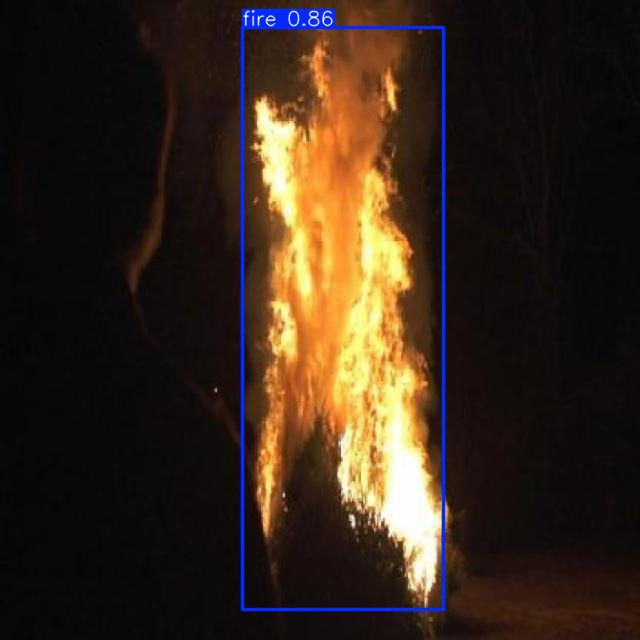

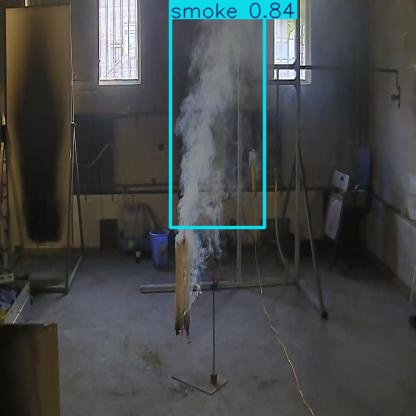

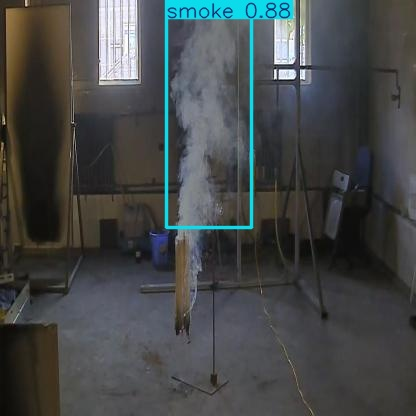

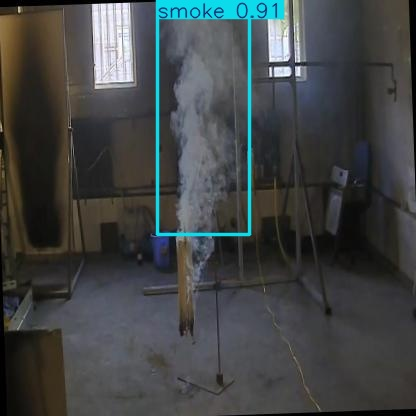

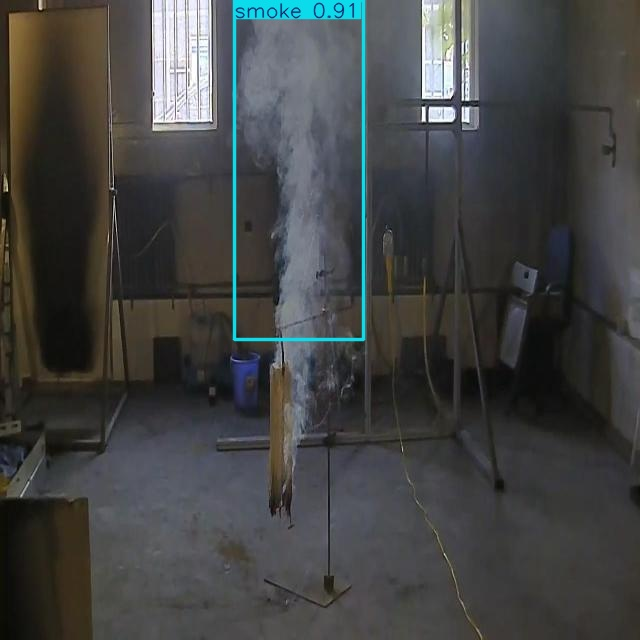

In [14]:
import os
from IPython.display import Image, display

pred_dir = Path("/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_predictions/test_predictions")

pred_files = sorted([p for p in pred_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

print("Number of predicted images:", len(pred_files))

for p in pred_files[:5]:
    display(Image(filename=str(p)))

In [ ]:
CLASS_NAMES = {0: "fire", 1: "smoke"}

def image_verification_decision(result, conf_threshold=0.40):
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return {"decision": "none", "max_conf": 0.0, "detections": []}

    detections = []
    for box in boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        label = CLASS_NAMES.get(cls_id, str(cls_id))
        detections.append((label, conf))

    detections = [(label, conf) for label, conf in detections if conf >= conf_threshold]

    if not detections:
        return {"decision": "none", "max_conf": 0.0, "detections": []}

    labels_present = [d[0] for d in detections]
    max_conf = max(d[1] for d in detections)

    if "fire" in labels_present:
        return {"decision": "fire", "max_conf": max_conf, "detections": detections}
    elif "smoke" in labels_present:
        return {"decision": "smoke", "max_conf": max_conf, "detections": detections}
    else:
        return {"decision": "none", "max_conf": 0.0, "detections": []}

In [16]:
def multimodal_fusion(sensor_pred, image_result_dict):
    img_decision = image_result_dict["decision"]

    if sensor_pred == "Background":
        if img_decision == "none":
            return {
                "final_status": "No Alert",
                "reason": "Sensor branch says normal background and image branch found no visible hazard."
            }
        elif img_decision == "smoke":
            return {
                "final_status": "Medium Alert",
                "reason": "Sensor branch says background, but image branch detected smoke."
            }
        elif img_decision == "fire":
            return {
                "final_status": "High Alert",
                "reason": "Sensor branch says background, but image branch detected fire."
            }

    if sensor_pred == "Nuisance":
        if img_decision == "none":
            return {
                "final_status": "Low Alert",
                "reason": "Sensor says nuisance and image branch found no visible hazard."
            }
        elif img_decision == "smoke":
            return {
                "final_status": "Medium Alert",
                "reason": "Sensor says nuisance and image branch detected smoke."
            }
        elif img_decision == "fire":
            return {
                "final_status": "High Alert",
                "reason": "Sensor says nuisance, but image branch detected fire."
            }

    if sensor_pred == "Fire":
        if img_decision == "fire":
            return {
                "final_status": "High Alert",
                "reason": "Sensor branch indicates fire and image branch confirmed visible fire."
            }
        elif img_decision == "smoke":
            return {
                "final_status": "High Alert",
                "reason": "Sensor branch indicates fire and image branch confirmed smoke."
            }
        elif img_decision == "none":
            return {
                "final_status": "Medium Alert",
                "reason": "Sensor branch indicates fire, but image branch found no visible confirmation."
            }

    return {
        "final_status": "Unknown",
        "reason": "Unexpected sensor prediction."
    }

In [17]:
img_path = str(next((DATASET_ROOT / "test/images").glob("*")))

result = detector.predict(
    source=img_path,
    imgsz=640,
    conf=0.25,
    verbose=False
)[0]

img_decision = image_verification_decision(result, conf_threshold=0.40)
print("Image decision:", img_decision)

# Replace this later with the real output from your sensor model
#sensor_pred = sensor_decision(X_test[0])
sensor_pred = "Fire"

final_decision = multimodal_fusion(sensor_pred, img_decision)
print("Final fusion:", final_decision)

Image decision: {'decision': 'fire', 'max_conf': 0.6660302877426147, 'detections': [('fire', 0.6660302877426147), ('fire', 0.6196780800819397)]}
Final fusion: {'final_status': 'High Alert', 'reason': 'Sensor branch indicates fire and image branch confirmed visible fire.'}


In [18]:
summary_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolov8n_results_summary.txt"

with open(summary_path, "w") as f:
    f.write("Indoor Fire/Smoke Detection Results\n")
    f.write("=================================\n\n")
    f.write(f"Best model path: {best_model_path}\n")
    f.write(f"Fixed YAML path: {fixed_yaml_path}\n\n")
    f.write("Validation metrics:\n")
    f.write(str(val_metrics))
    f.write("\n\nTest metrics:\n")
    f.write(str(test_metrics))

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolov8n_results_summary.txt


# Evaluation of the YOLO Model on Video Data

In [20]:
# import libraries
import cv2
import os
from ultralytics import YOLO
from collections import Counter

In [21]:
# Load the trained YOLO model
model_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/yolo_models/indoor_fire_smoke_yolov8n/weights/best.pt"
model = YOLO(model_path)

print("Model loaded successfully")

Model loaded successfully


In [37]:
# Function to test the trained YOLO model on a video,
# save the annotated output video, and return a summary of detections.

def test_yolo_on_video(video_path, output_path, model, conf_threshold=0.25):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    # Video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # Save output video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    detected_labels = []
    max_conf_per_class = {}

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Predict
        results = model.predict(frame, conf=conf_threshold, verbose=False)
        result = results[0]

        # Draw annotated frame
        annotated_frame = result.plot()
        out.write(annotated_frame)

        # Collect detections
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                cls_id = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                label = model.names[cls_id]

                detected_labels.append(label)

                if label not in max_conf_per_class:
                    max_conf_per_class[label] = conf
                else:
                    max_conf_per_class[label] = max(max_conf_per_class[label], conf)

    cap.release()
    out.release()

    # Summary
    detection_counts = Counter(detected_labels)

    summary = {
        "video_path": video_path,
        "output_path": output_path,
        "total_frames": frame_count,
        "detection_counts": dict(detection_counts),
        "max_conf_per_class": max_conf_per_class
    }

    return summary

In [38]:
# video of fire

video_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/test_videos_fire_detection/fire_1.mp4"
output_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/results_test_video/fire_1_result.mp4"

summary = test_yolo_on_video(video_path, output_path, model)

print(summary)

from IPython.display import Video

Video(output_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [33]:
# video of fire and smoke

video_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/test_videos_fire_detection/fire_smoke_1.mp4"
output_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/results_test_video/fire_smoke_1_result.mp4"

summary = test_yolo_on_video(video_path, output_path, model)

print(summary)

from IPython.display import Video

Video(output_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [34]:
#video of normal

video_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/test_videos_fire_detection/normal_1.mp4"
output_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/results_test_video/normal_1_result.mp4"

summary = test_yolo_on_video(video_path, output_path, model)

print(summary)

from IPython.display import Video

Video(output_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [35]:
# video of normal

video_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/test_videos_fire_detection/normal_2.mp4"
output_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/results_test_video/normal_2_result.mp4"

summary = test_yolo_on_video(video_path, output_path, model)

print(summary)

from IPython.display import Video

Video(output_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [36]:
# video of smoke

video_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/test_videos_fire_detection/smoke_1.mp4"
output_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/results_test_video/smoke_1_result.mp4"

summary = test_yolo_on_video(video_path, output_path, model)

print(summary)

from IPython.display import Video

Video(output_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.

| Video Name | Scenario | Expected | Model Output  | Confidence  | Notes                                         |
| ---------- | -------- | -------- | ------------- | ----------- | --------------------------------------------- |
| fire_1.mp4 | Fire     | Fire     | Fire detected | High (0.84) | Strong and consistent detection across frames |
| fire_1.mp4 | Fire + Smoke     | Fire + Smoke     | Fire and smoke detected | High (fire: 0.89, smoke: 0.88) | Excellent detection of both fire and smoke with high confidence |
| normal_1.mp4 | Normal   | No detection | No detection |    -     | No false alarms, correct behavior |
| normal_2.mp4 | Normal   | No detection | Smoke detected (false positive) | Medium (~0.50) | Minor false positives with moderate confidence |
| smoke_1.mp4 | Smoke    | Smoke    | Smoke detected | High (0.84) | Strong and consistent smoke detection |




